<a href="https://colab.research.google.com/github/DinRazar/neural_networks/blob/main/%D0%A0%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №4. Построение сверточной нейронной сети для классификации изображений, с использованием BatchNormalization() и Dropout()**

## **Задание 1. Построение сверточной нейронной сети для классификации изображений из датасета CIFAR-100, с использованием BatchNormalization() и Dropout():**



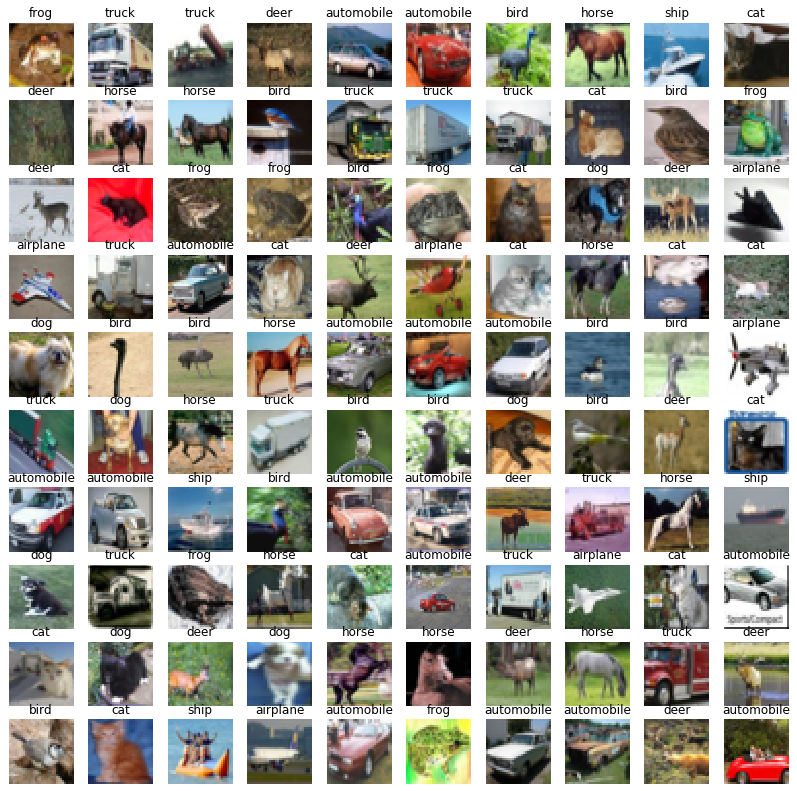

### **1.1. Загрузите исходный датасет. Разделите его на обучающую и тестовую выборки:**



*P.S.: Не забудьте обратить внимание на размерность (shape) исходных данных и при необходимости измените её (см. примеры из предыдущих занятий)*

[Информация о датасете](https://www.cs.toronto.edu/%7Ekriz/cifar.html)

[Техническая документация по использованию датасета в Keras](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/cifar100/load_data)





In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import warnings
from pylab import rcParams
from keras.datasets import cifar100
from keras.layers import Activation
from keras.layers import BatchNormalization
from keras.optimizers import Adam, SGD
from keras.layers import Dropout
from keras.layers import Conv2D
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import MaxPooling2D
from keras.models import Sequential
from keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print('Train: X = ', x_train.shape)
print('Test: X = ', x_test.shape)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: X =  (50000, 32, 32, 3)
Test: X =  (10000, 32, 32, 3)


### **1.2. Визуализируйте несколько изображений из датасета:**


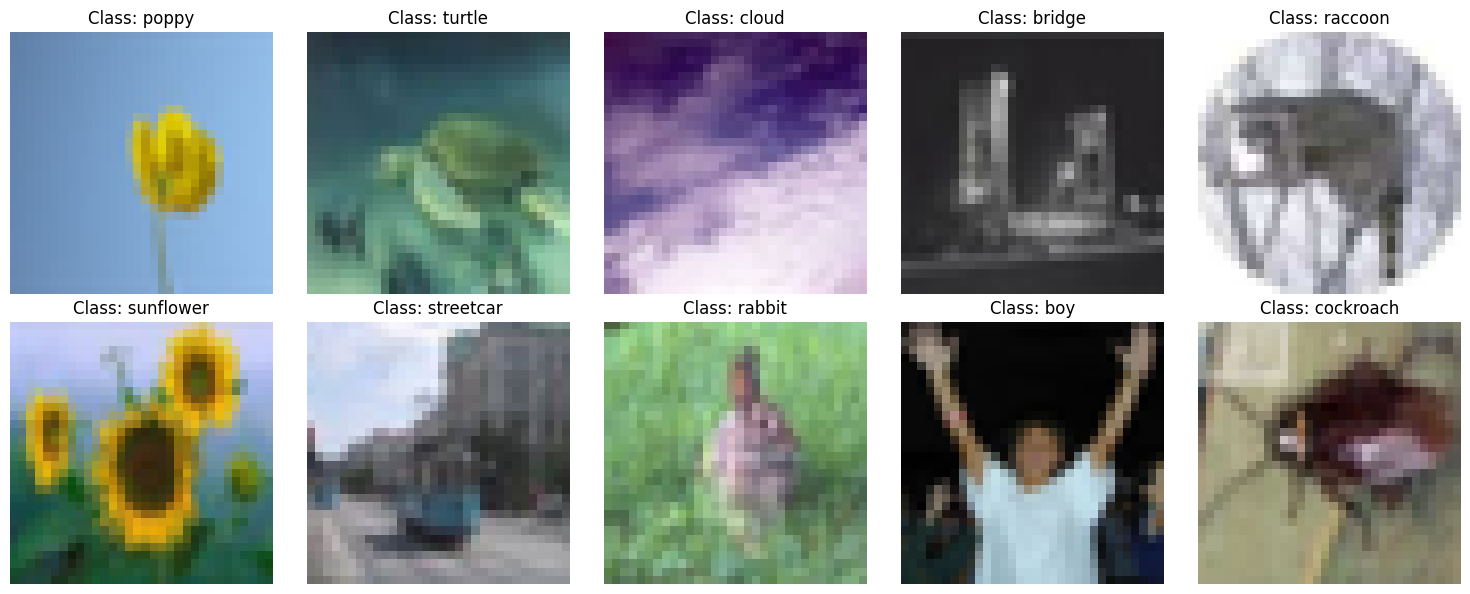

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Список названий классов CIFAR-100
cifar100_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank',
    'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

# Визуализация 10 случайных изображений
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = np.random.randint(0, len(x_train))
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx])
    plt.title(f"Class: {cifar100_labels[y_train[idx][0]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### **1.3. Произведите нормализацию данных:**

In [ ]:
from tensorflow import keras

x_train_n = x_train / 255
x_test_n = x_test / 255

y_train_n = keras.utils.to_categorical(y_train, 100)
y_test_n = keras.utils.to_categorical(y_test, 100)

print(x_train_n.shape)
print(x_test_n.shape)


(50000, 32, 32, 3)
(10000, 32, 32, 3)


### **1.4. Создайте модель сверточной нейронной сети для решения поставленной задачи без использования BatchNormalization() и Dropout():**

Имя данной модели: model_1

In [ ]:
model_1 = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(100,  activation='softmax')
])

model_1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 909,092 (3.47 MB)

 Trainable params: 909,092 (3.47 MB)

 Non-trainable params: 0 (0.00 B)

Обучите созданную модель

In [ ]:
model_1.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

EPOCHS = 10
BATCH = 100

model_1_history = model_1.fit(x_train_n, y_train_n,
                              batch_size=BATCH,
                              epochs=EPOCHS,
                              verbose=1,
                              validation_data=(x_test_n, y_test_n))

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 122ms/step - accuracy: 0.1254 - loss: 3.7952 - val_accuracy: 0.2094 - val_loss: 3.2640
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 124ms/step - accuracy: 0.2669 - loss: 2.9828 - val_accuracy: 0.3031 - val_loss: 2.8052
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 122ms/step - accuracy: 0.3470 - loss: 2.5880 - val_accuracy: 0.3499 - val_loss: 2.5794
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 121ms/step - accuracy: 0.4008 - loss: 2.3137 - val_accuracy: 0.3771 - val_loss: 2.4367
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 127ms/step - accuracy: 0.4539 - loss: 2.0888 - val_accuracy: 0.3981 - val_loss: 2.3754
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.4992 - loss: 1.8897 - val_accuracy: 0.4149 - val_loss: 2.3234
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 122ms/step - accuracy: 0.5424 - loss: 1.6992 - val_accuracy: 0.4206 - val_loss: 2.3381
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 128ms/step - accuracy: 0.5832 - loss: 1

### **1.5. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием BatchNormalization():**

Имя данной модели: model_2

In [ ]:
model_2 = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dense(100,  activation='softmax')
])

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 910,500 (3.47 MB)

 Trainable params: 909,796 (3.47 MB)

 Non-trainable params: 704 (2.75 KB)

Обучите созданную модель

In [ ]:
model_2.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

EPOCHS = 10
BATCH = 100
model_2_history = model_2.fit(x_train_n, y_train_n,
                              batch_size=BATCH,
                              epochs=EPOCHS,
                              verbose=1,
                              validation_data=(x_test_n, y_test_n))

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 160ms/step - accuracy: 0.2577 - loss: 3.1154 - val_accuracy: 0.2589 - val_loss: 3.0764
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 156ms/step - accuracy: 0.4448 - loss: 2.1538 - val_accuracy: 0.3641 - val_loss: 2.5375
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 80s 159ms/step - accuracy: 0.5622 - loss: 1.6342 - val_accuracy: 0.3808 - val_loss: 2.5851
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 161ms/step - accuracy: 0.6869 - loss: 1.1514 - val_accuracy: 0.4214 - val_loss: 2.4264
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 78s 155ms/step - accuracy: 0.8059 - loss: 0.7074 - val_accuracy: 0.3959 - val_loss: 2.8224
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 159ms/step - accuracy: 0.8987 - loss: 0.3890 - val_accuracy: 0.4019 - val_loss: 2.9630
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 169ms/step - accuracy: 0.9464 - loss: 0.2171 - val_accuracy: 0.3996 - val_loss: 3.1724
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 79s 159ms/step - accuracy: 0.9651 - loss: 0

### **1.6. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout():**

Имя данной модели: model_3

In [ ]:

model_3 = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2), strides=2),
    Dropout(0.25),
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    MaxPooling2D((2, 2), strides=2),
    Dropout(0.25),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    Dropout(0.4),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='softmax')
])


Обучите созданную модель

In [ ]:
model_3.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

model_3_history = model_3.fit(x_train_n, y_train_n,
                              batch_size=BATCH,
                              epochs=EPOCHS,
                              verbose=1,
                              validation_data=(x_test_n, y_test_n))

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 132ms/step - accuracy: 0.0510 - loss: 4.2495 - val_accuracy: 0.1337 - val_loss: 3.8069
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 133ms/step - accuracy: 0.1221 - loss: 3.7448 - val_accuracy: 0.2030 - val_loss: 3.4033
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.1624 - loss: 3.5080 - val_accuracy: 0.2358 - val_loss: 3.1870
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 131ms/step - accuracy: 0.1859 - loss: 3.3562 - val_accuracy: 0.2642 - val_loss: 3.0537
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 129ms/step - accuracy: 0.2078 - loss: 3.2469 - val_accuracy: 0.2928 - val_loss: 2.8976
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - accuracy: 0.2227 - loss: 3.1644 - val_accuracy: 0.2948 - val_loss: 2.8936
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.2380 - loss: 3.0806 - val_accuracy: 0.3215 - val_loss: 2.7511
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 130ms/step - accuracy: 0.2476 - loss: 3

### **1.7. Создайте модель сверточной нейронной сети для решения поставленной задачи с использованием Dropout() и BatchNormalization().**

См. рекомендации [здесь](https://stackoverflow.com/questions/39691902/ordering-of-batch-normalization-and-dropout) и [здесь](https://www.kaggle.com/code/ryanholbrook/dropout-and-batch-normalization/)

Имя данной модели: model_4

In [ ]:
model_4 = Sequential([
    Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),
    Dropout(0.25),
    Conv2D(64, (3,3), padding='valid', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),
    Dropout(0.25),
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(100, activation='softmax')
])

model_4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 910,500 (3.47 MB)

 Trainable params: 909,796 (3.47 MB)

 Non-trainable params: 704 (2.75 KB)

Обучите созданную модель

In [ ]:
model_4.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

model_4_history = model_4.fit(x_train_n, y_train_n,
                              batch_size=BATCH,
                              epochs=EPOCHS,
                              verbose=1,
                              validation_data=(x_test_n, y_test_n))

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 89s 173ms/step - accuracy: 0.1088 - loss: 4.0209 - val_accuracy: 0.1515 - val_loss: 3.6659
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 176ms/step - accuracy: 0.2207 - loss: 3.2408 - val_accuracy: 0.3106 - val_loss: 2.7851
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 89s 178ms/step - accuracy: 0.2826 - loss: 2.8855 - val_accuracy: 0.2710 - val_loss: 2.9729
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 89s 179ms/step - accuracy: 0.3198 - loss: 2.6828 - val_accuracy: 0.3562 - val_loss: 2.5540
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 139s 173ms/step - accuracy: 0.3467 - loss: 2.5470 - val_accuracy: 0.3887 - val_loss: 2.3809
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 172ms/step - accuracy: 0.3705 - loss: 2.4453 - val_accuracy: 0.3981 - val_loss: 2.3133
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 173ms/step - accuracy: 0.3868 - loss: 2.3625 - val_accuracy: 0.3709 - val_loss: 2.4676
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 172ms/step - accuracy: 0.3998 - los

### **Задание 1.8. Пойстройте график обучения для каждой модели. Сделайте выводы по каждому из них. Подведите итог и выделите наиболее удачную модель:**

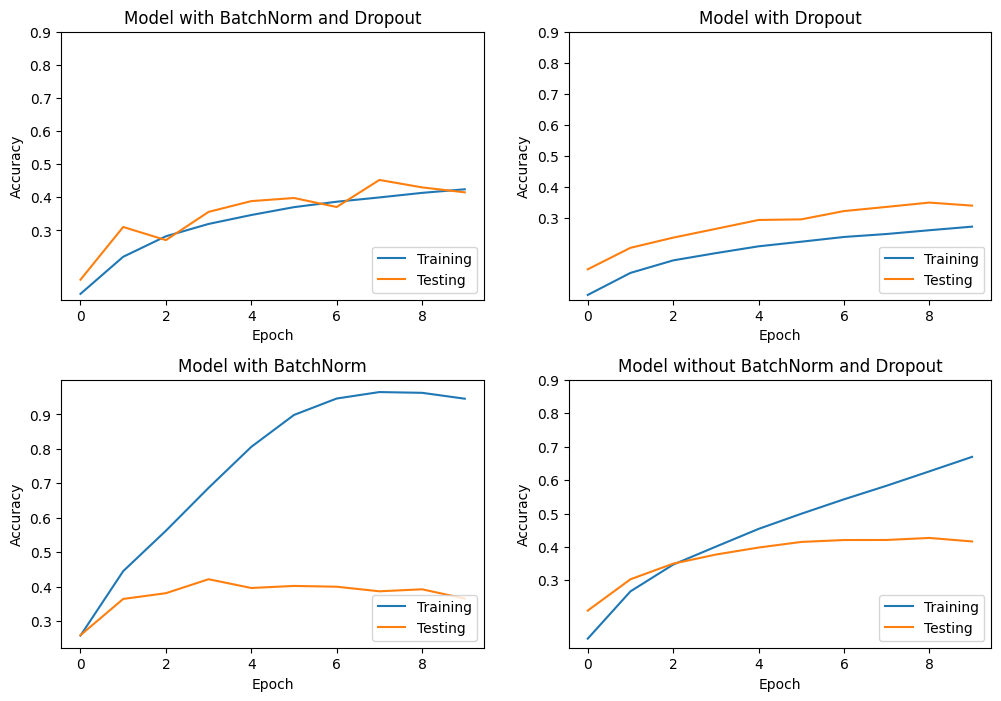

In [ ]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(model_4_history.history['accuracy'], label='Training')
plt.plot(model_4_history.history['val_accuracy'], label='Testing')
plt.title('Model with BatchNorm and Dropout')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

plt.subplot(2, 2, 2)
plt.plot(model_3_history.history['accuracy'], label='Training')
plt.plot(model_3_history.history['val_accuracy'], label='Testing')
plt.title('Model with Dropout')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

plt.subplot(2, 2, 3)
plt.plot(model_2_history.history['accuracy'], label='Training')
plt.plot(model_2_history.history['val_accuracy'], label='Testing')
plt.title('Model with BatchNorm')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

plt.subplot(2, 2, 4)
plt.plot(model_1_history.history['accuracy'], label='Training')
plt.plot(model_1_history.history['val_accuracy'], label='Testing')
plt.title('Model without BatchNorm and Dropout')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

plt.subplots_adjust(hspace=0.3)

plt.show()

Ваши выводы

Ваш итог

### **1.9. Визуализируйте карты активации модели с BatchNorm() и Dropout(),отдельно по 5 классам (на Ваш выбор):**

In [ ]:
def visualize_act_map(model, img_input):
    """
    Универсальная функция для визуализации активаций сверточных слоев.

    Args:
        model: Модель Keras (Sequential или Functional)
        img_input: Входное изображение или батч изображений
    """
    # Убеждаемся, что входные данные представлены в правильной размерности
    if len(np.array(img_input).shape) == 3:
        img_input = np.expand_dims(img_input, axis=0)

    # Конвертируем входные данные в тензор
    input_tensor = tf.convert_to_tensor(img_input)

    # Обрабатываем входные данные по слоям, не создавая новую модель
    x = input_tensor

    # Находим и визуализируем карты активации сверточных слоев
    for layer in model.layers:
        # Применяем слой напрямую
        x = layer(x)

        # Визуализируем, если это сверточный или пулинговый слой
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.MaxPooling2D, tf.keras.layers.AveragePooling2D)):
            # Конвертируем активации в numpy-массив
            activation = x.numpy()

            n_features = activation.shape[-1]
            print(f"Визуализация слоя: {layer.name}, форма: {activation.shape}")

            # Настраиваем размеры сетки
            cols = min(16, n_features)
            rows = (n_features + cols - 1) // cols

            # Создаем фигуру
            plt.figure(figsize=(cols * 1.5, rows * 1.5))
            plt.suptitle(f'Активации слоя {layer.name}', fontsize=16)

            # Отображаем каждую карту признаков
            for j in range(n_features):
                plt.subplot(rows, cols, j + 1)

                # Получаем карту признаков
                feature_map = activation[0, :, :, j]

                # Нормализуем для лучшей визуализации
                mean = feature_map.mean()
                std = feature_map.std()

                if std > 0:
                    feature_map = (feature_map - mean) / std

                # Ограничиваем значения для лучшей визуализации
                feature_map = np.clip(feature_map, -3, 3)

                plt.imshow(feature_map, cmap='viridis')
                plt.title(f'{j}')
                plt.axis('off')

            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()

Визуализация слоя: conv2d_9, форма: (1, 32, 32, 32)


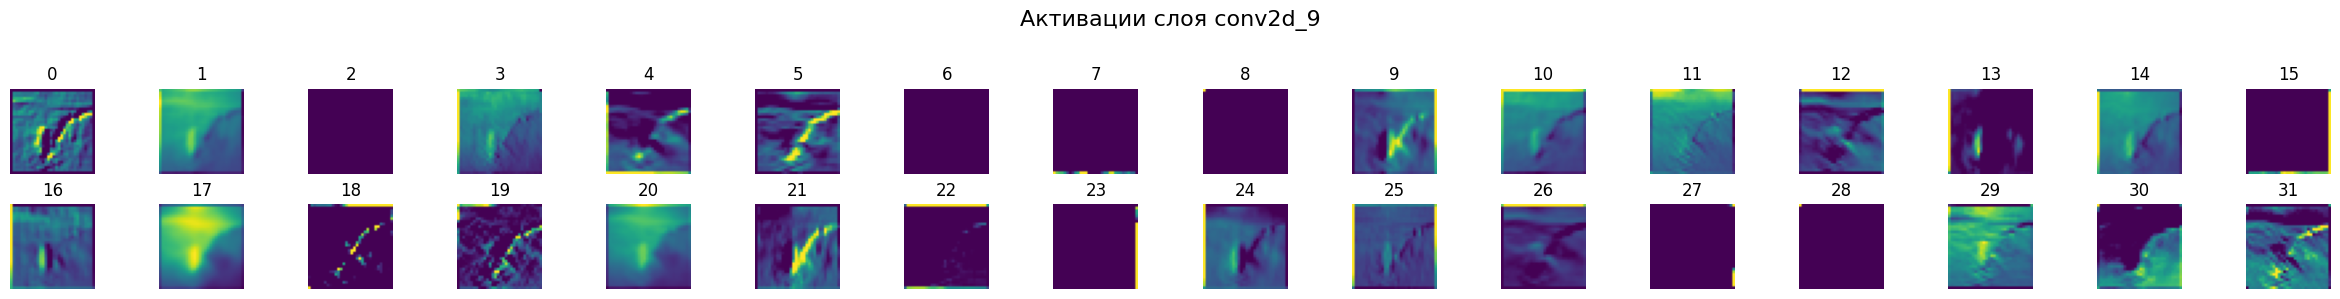

Визуализация слоя: max_pooling2d_6, форма: (1, 16, 16, 32)


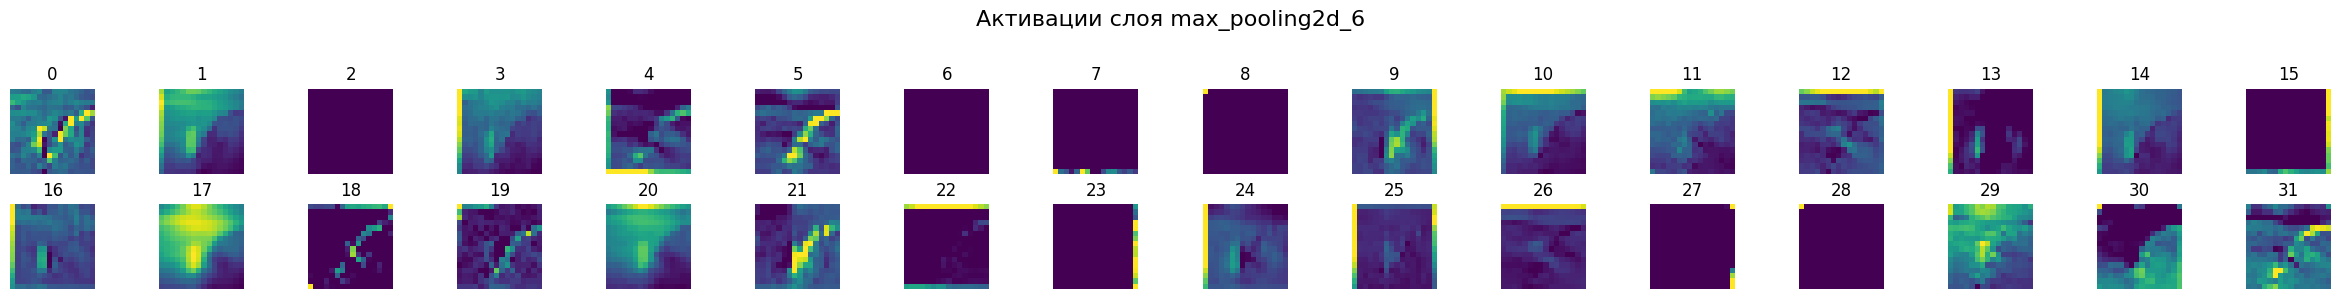

Визуализация слоя: conv2d_10, форма: (1, 14, 14, 64)


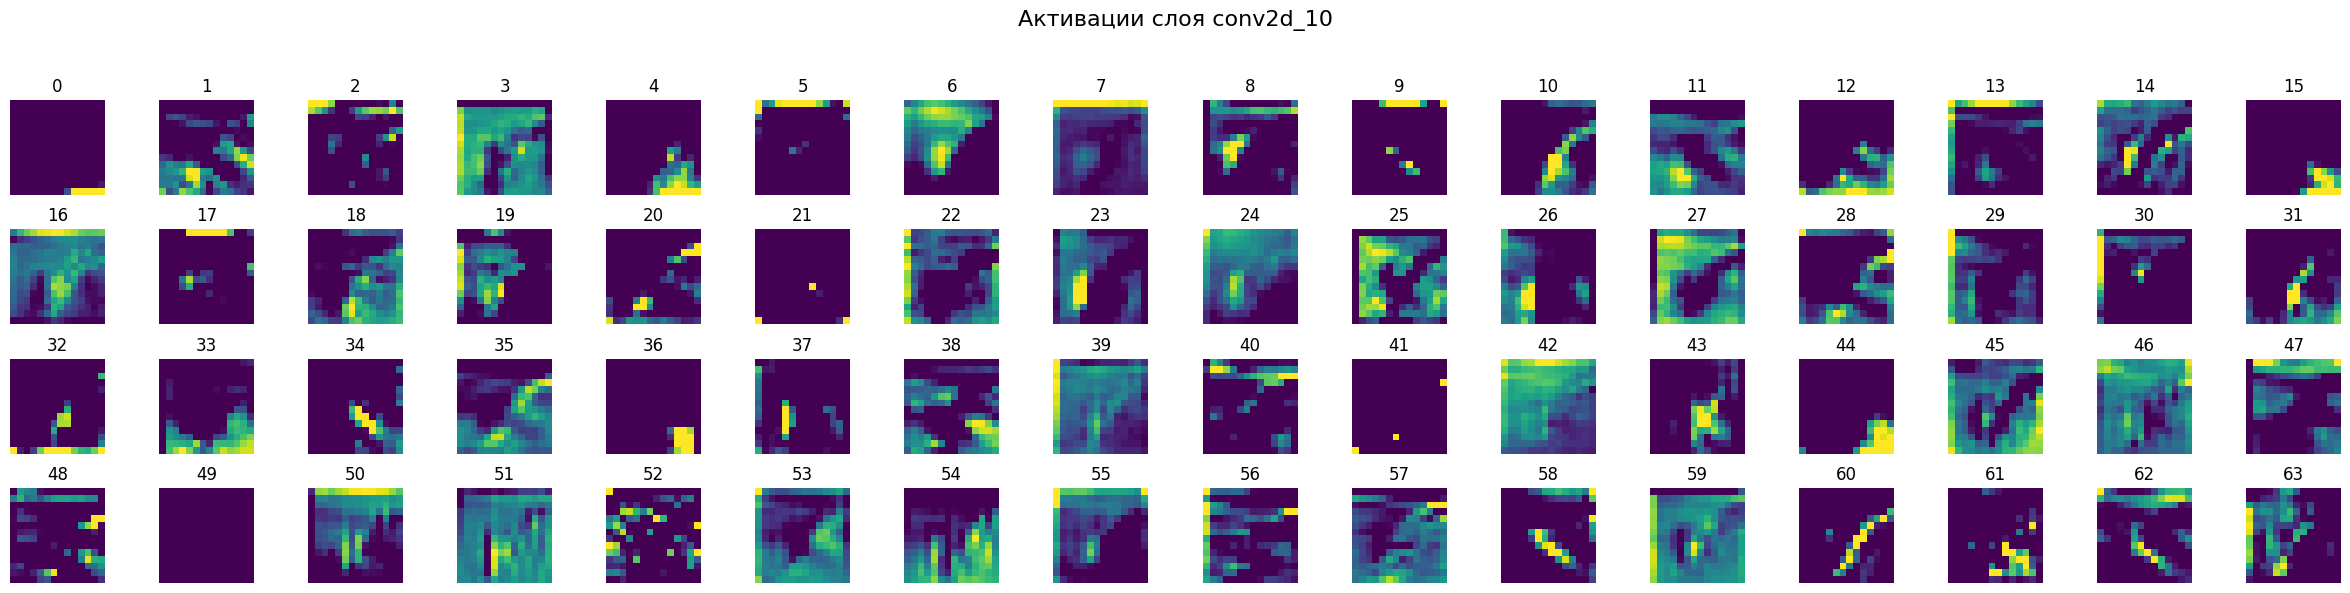

Визуализация слоя: max_pooling2d_7, форма: (1, 7, 7, 64)


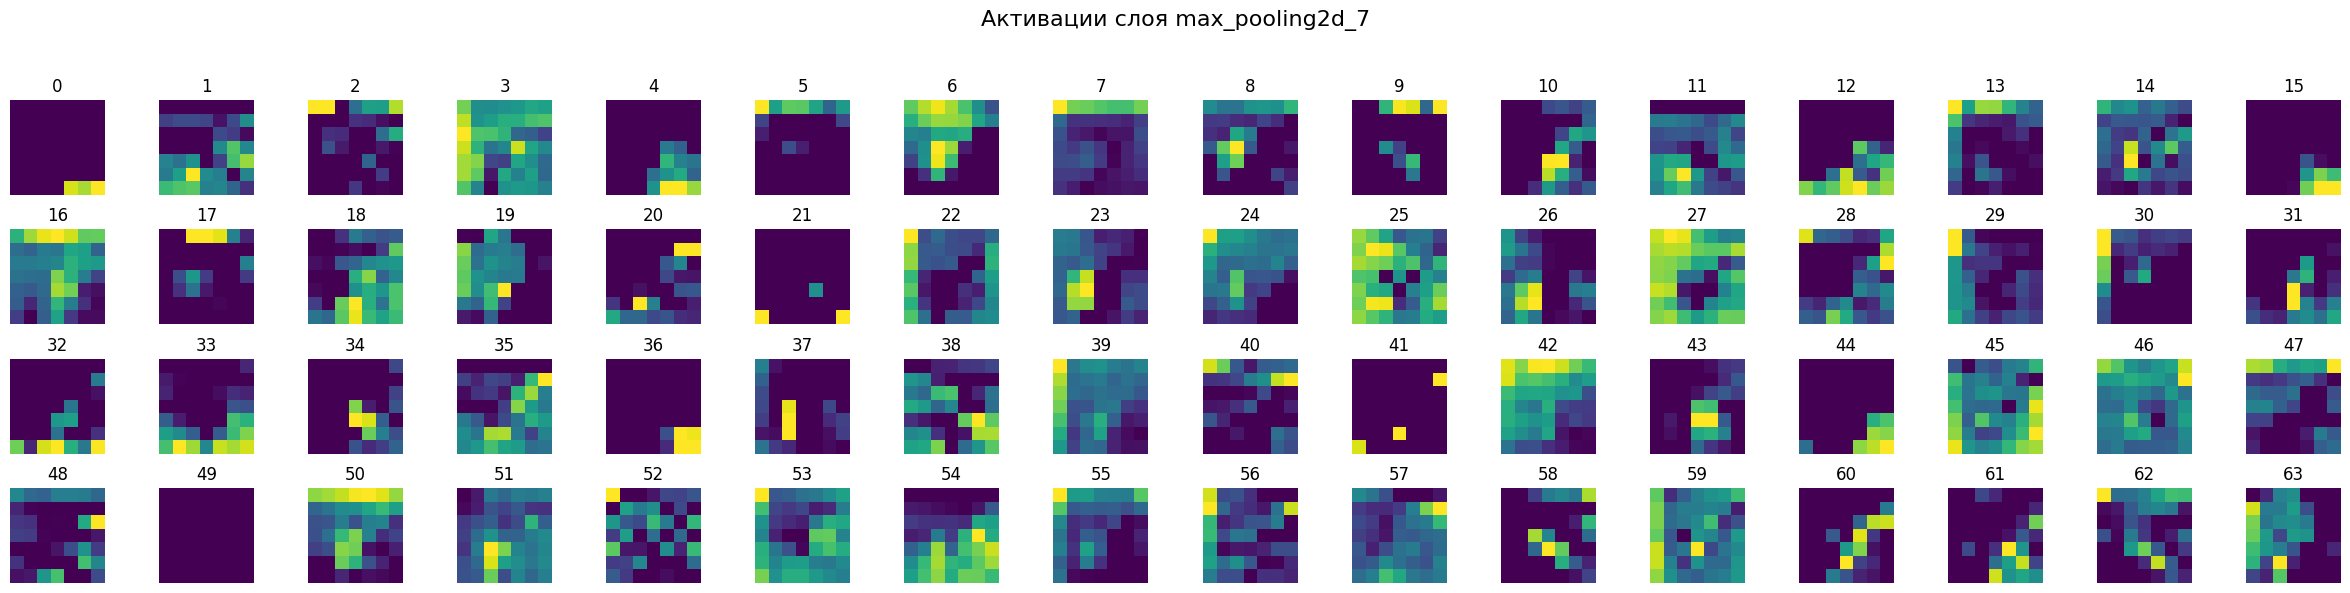

Визуализация слоя: conv2d_11, форма: (1, 7, 7, 128)


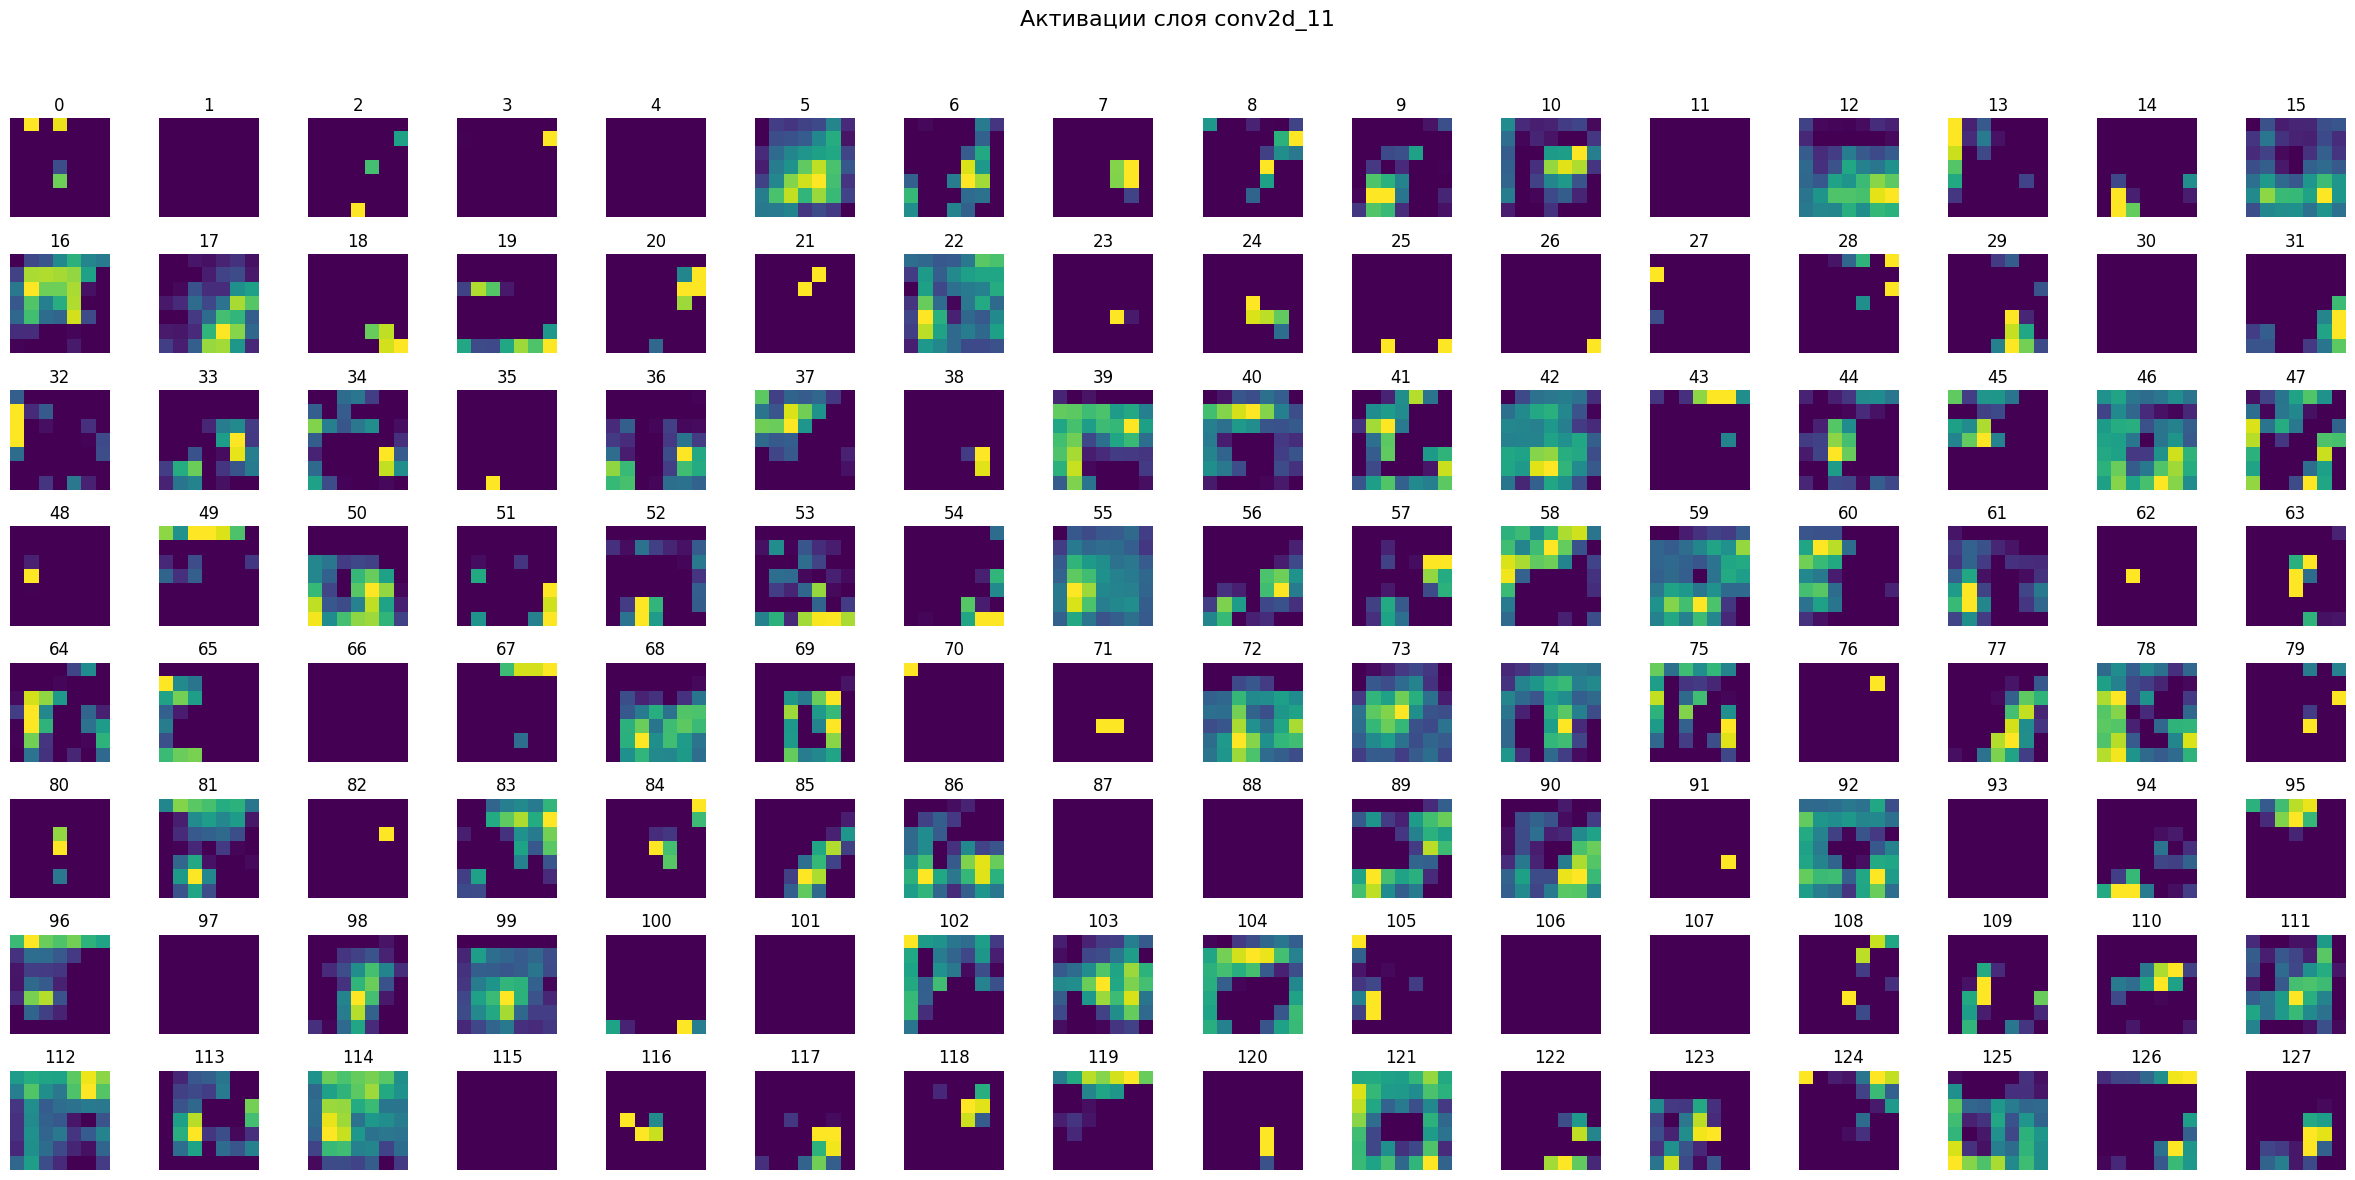

In [ ]:
visualize_act_map(model_4, x_train_n[8])

## **Задание 2. Загрузите Ваш датасет из предыдущей работы. Разделите его на обучающую и тестовую выборки. Обучите модель классификации с применением BatchNorm() и Dropout(). Сравните точность с моделями, обученными Вами ранее. Визуализируйте карты активаций.**

Размер обучающей выборки: (15000, 32, 32, 3)
Размер тестовой выборки: (3000, 32, 32, 3)
Количество классов: 3
Названия классов: ['airplane', 'ship', 'truck']
Распределение классов в обучающей выборке: {'airplane': np.int64(5000), 'ship': np.int64(5000), 'truck': np.int64(5000)}


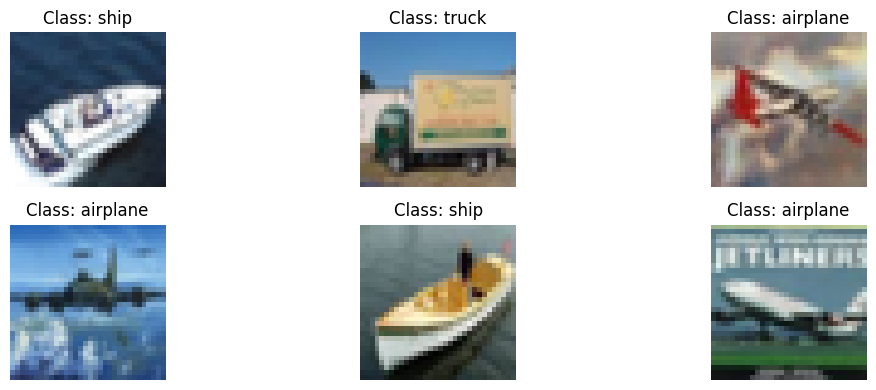

После нормализации - диапазон: [0.0, 1.0]
Форма меток one-hot: (15000, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,341,475 (5.12 MB)

 Trainable params: 1,339,555 (5.11 MB)

 Non-trainable params: 1,920 (7.50 KB)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 114s 895ms/step - accuracy: 0.6565 - loss: 0.9667 - val_accuracy: 0.3397 - val_loss: 2.6505
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 105s 871ms/step - accuracy: 0.7805 - loss: 0.5700 - val_accuracy: 0.4417 - val_loss: 2.2785
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 105s 875ms/step - accuracy: 0.8269 - loss: 0.4410 - val_accuracy: 0.4413 - val_loss: 2.3756
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 141s 865ms/step - accuracy: 0.8574 - loss: 0.3644 - val_accuracy: 0.6223 - val_loss: 0.9933
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 142s 868ms/step - accuracy: 0.8827 - loss: 0.3072 - val_accuracy: 0.8407 - val_loss: 0.4085
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 113s 943ms/step - accuracy: 0.8953 - loss: 0.2711 - val_accuracy: 0.8713 - val_loss: 0.3417
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 109s 911ms/step - accuracy: 0.9089 - loss: 0.2343 - val_accuracy: 0.9073 - val_loss: 0.2573
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 104s 868ms/step - accuracy: 0.9152 -

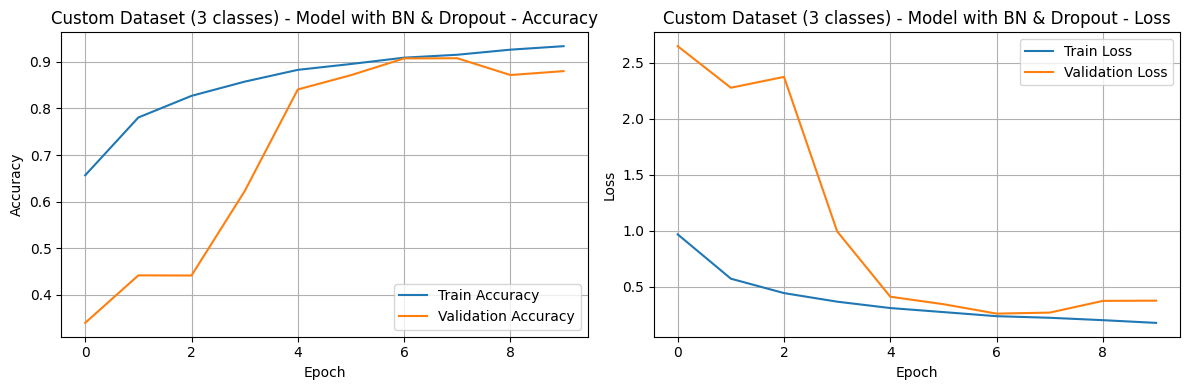


Точность на тестовой выборке: 0.8700
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step

Матрица ошибок:
[[709 203  88]
 [ 15 951  34]
 [ 15  35 950]]

Отчет по классификации:
              precision    recall  f1-score   support

    airplane       0.96      0.71      0.82      1000
        ship       0.80      0.95      0.87      1000
       truck       0.89      0.95      0.92      1000

    accuracy                           0.87      3000
   macro avg       0.88      0.87      0.87      3000
weighted avg       0.88      0.87      0.87      3000



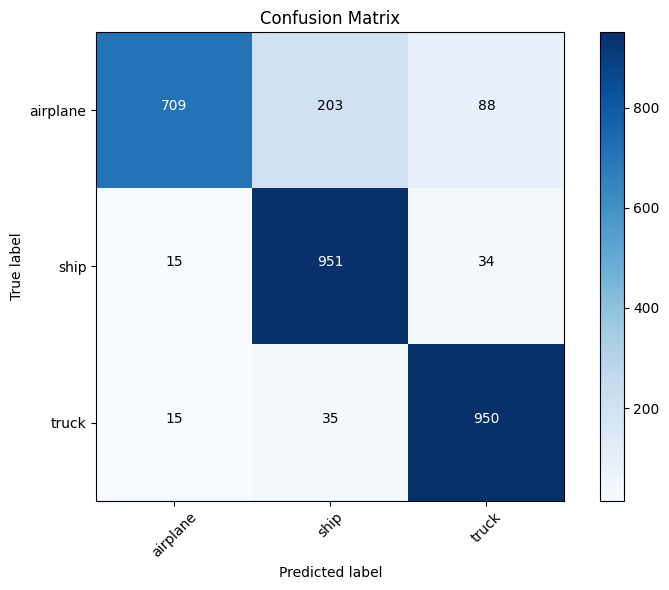


=== Сравнение с предыдущими моделями ===


NameError: name 'test_acc_4' is not defined

In [ ]:
# 2. Загрузите Ваш датасет из предыдущей работы
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np

# Загружаем данные CIFAR-10
(X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()

# Определяем названия классов для CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Выбираем только первые 3 класса (индексы 0, 8, 9)
classes_to_use = [0, 8, 9]  # airplane, ship, truck

# Создаем маски для выбора нужных классов
train_mask = np.isin(y_train_full, classes_to_use).flatten()
test_mask = np.isin(y_test_full, classes_to_use).flatten()

# Фильтруем данные
X_train = X_train_full[train_mask]
y_train = y_train_full[train_mask]
X_test = X_test_full[test_mask]
y_test = y_test_full[test_mask]

# Перенумеровываем метки (0, 1, 2)
label_mapping = {0: 0, 8: 1, 9: 2}
y_train = np.array([label_mapping[label[0]] for label in y_train])
y_test = np.array([label_mapping[label[0]] for label in y_test])

# Выводим информацию о данных
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Количество классов: {len(classes_to_use)}")
print(f"Названия классов: {[class_names[i] for i in classes_to_use]}")

# Проверяем распределение классов
unique, counts = np.unique(y_train, return_counts=True)
print(f"Распределение классов в обучающей выборке: {dict(zip([class_names[i] for i in classes_to_use], counts))}")

# Визуализация нескольких изображений из вашего датасета
plt.figure(figsize=(12, 4))
for i in range(6):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[idx])
    plt.title(f"Class: {class_names[classes_to_use[y_train[idx]]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Нормализация данных
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Преобразование меток в one-hot encoding
y_train_cat = to_categorical(y_train, 3)
y_test_cat = to_categorical(y_test, 3)

print(f"После нормализации - диапазон: [{X_train.min()}, {X_train.max()}]")
print(f"Форма меток one-hot: {y_train_cat.shape}")

# Создание модели с BatchNormalization и Dropout для вашего датасета
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

model_custom = Sequential([
    # Первый сверточный блок
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Второй сверточный блок
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Третий сверточный блок
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Полносвязные слои
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 класса
])

model_custom.summary()

# Компиляция модели
model_custom.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение модели
history_custom = model_custom.fit(
    X_train, y_train_cat,
    batch_size=100,
    epochs=10,
    validation_split=0.2,
    verbose=1
)

# Функция для построения графиков обучения
def plot_training_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # График точности
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    # График потерь
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

# Построение графиков обучения
plot_training_history(history_custom, "Custom Dataset (3 classes) - Model with BN & Dropout")

# Оценка точности на тестовой выборке
test_loss, test_accuracy = model_custom.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nТочность на тестовой выборке: {test_accuracy:.4f}")

# Детальный отчет по каждому классу
from sklearn.metrics import classification_report, confusion_matrix

# Получаем предсказания
y_pred = model_custom.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_classes)
print("\nМатрица ошибок:")
print(cm)

# Отчет по классификации
target_names = [class_names[i] for i in classes_to_use]
print("\nОтчет по классификации:")
print(classification_report(y_test, y_pred_classes, target_names=target_names))

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(target_names))
plt.xticks(tick_marks, target_names, rotation=45)
plt.yticks(tick_marks, target_names)
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Добавляем значения в ячейки
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

## **Сравнение моделей**


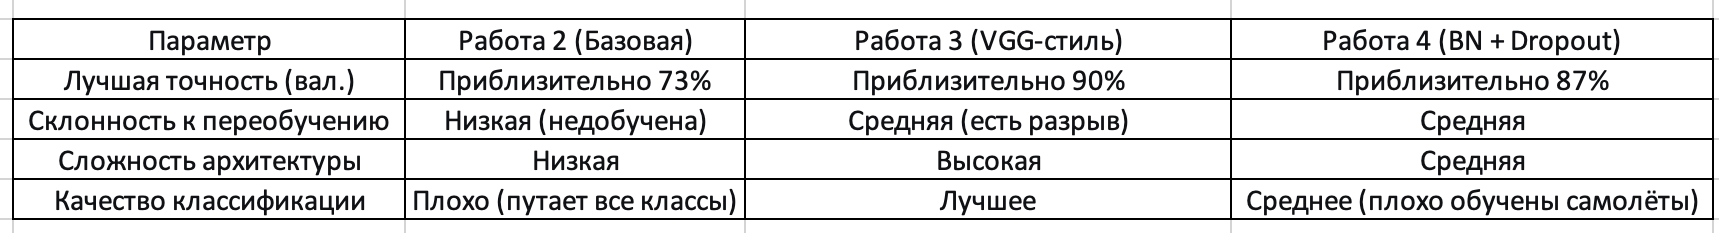

**Модель ИНС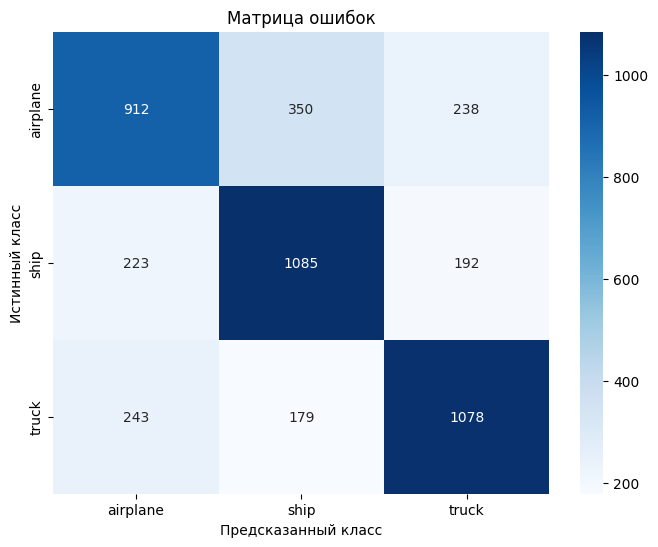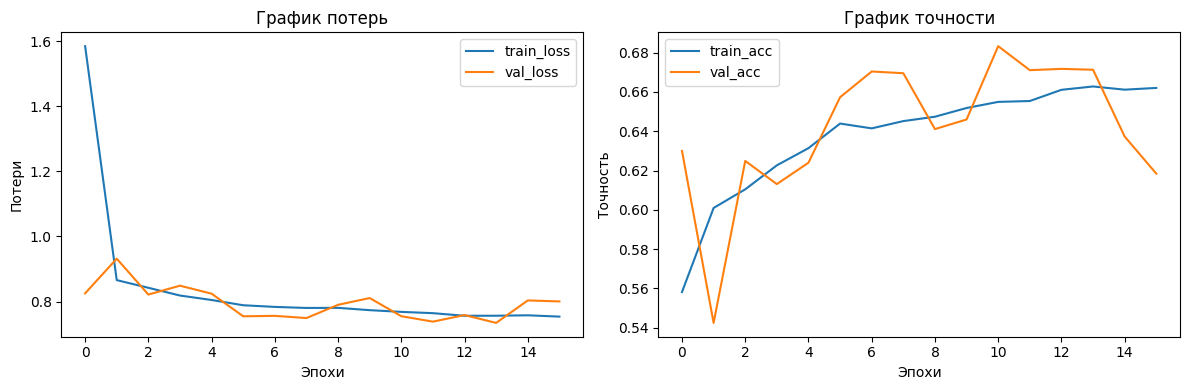**

**Свёрточная нейросеть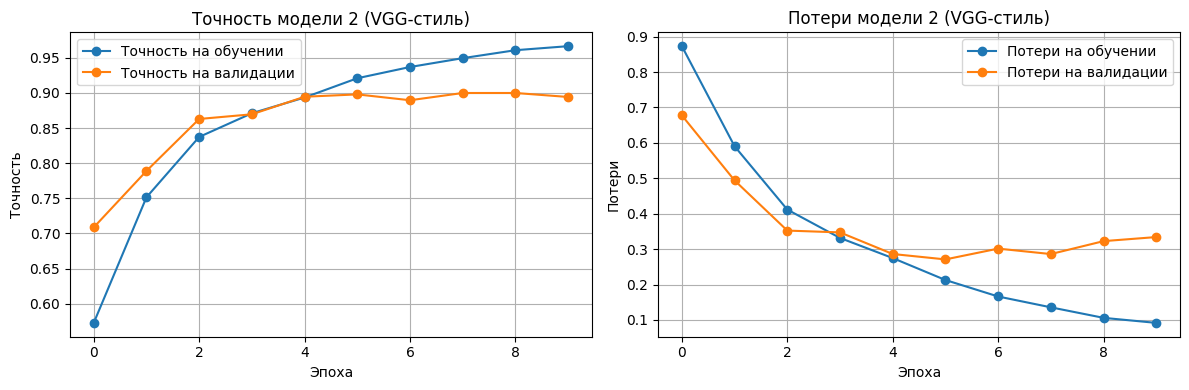**

**БатчНорм и ДропАут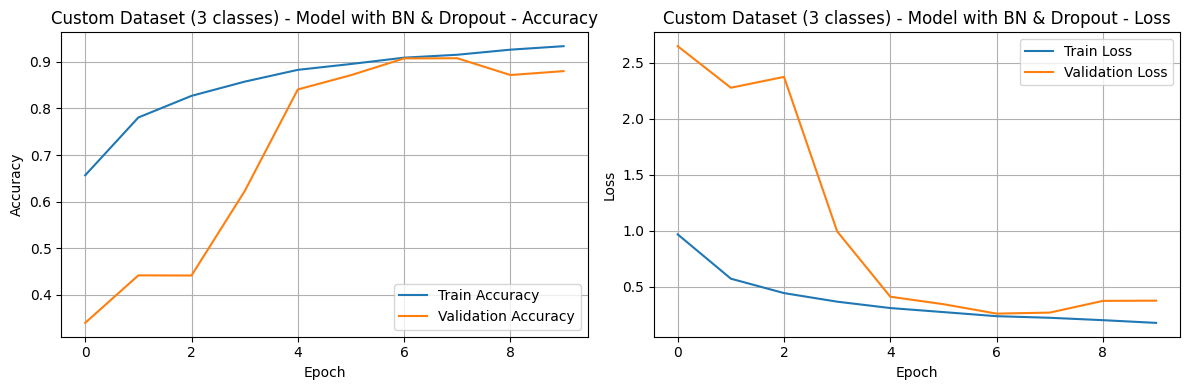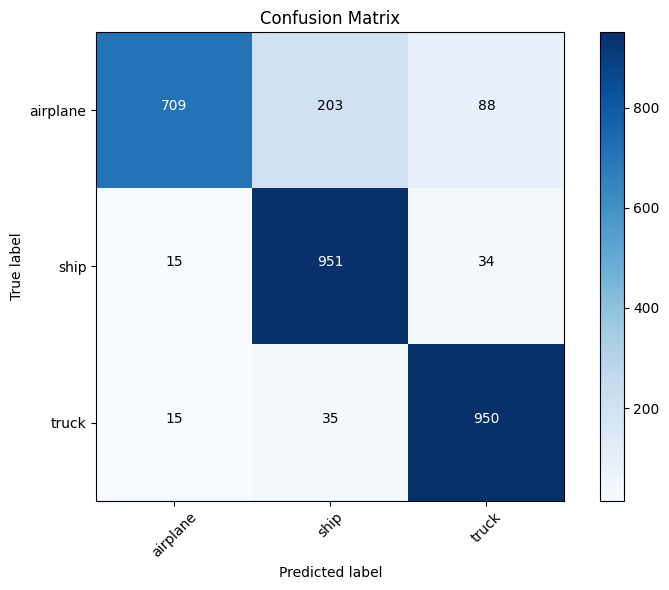**